# Stage 4A — Brute-force event-to-feature association

This correctness-reference experiment detects Shi–Tomasi features on one APS frame, initializes a read-only FeatureState memory, and evaluates events in that frame's following half-open APS interval. Every event is processed in stable chronological order; ties retain source order. A match requires strict `d² < R²` and `abs(Δt) < T`, without square roots. No match is rejected. Multiple eligible features mark the event ambiguous and select the smallest squared distance, breaking ties by lower feature ID. Each event is assigned at most once. Polarity is retained but not used. State updates and grid hashing are out of scope.

In [1]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "event_association.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.event_association as event_association
event_association = importlib.reload(event_association)
from src.aps_features import ShiTomasiConfig, extract_shi_tomasi_features
from src.feature_state_memory import initialize_from_aps_features

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
interval_index = min(678, len(windows) - 1)
window = windows.get_window(interval_index)
radius_px = 8.0
time_window_us = 50_000.0

features = extract_shi_tomasi_features(
    window.frame_k,
    ShiTomasiConfig(max_features=500),
    frame_index=interval_index,
    frame_timestamp_us=window.frame_k_common_time_us,
).features
memory = initialize_from_aps_features(
    features, window.frame_k_common_time_us, slot_count=500
)
result = event_association.associate_events_brute_force(
    window.events_k,
    memory,
    radius_px,
    time_window_us,
    event_timestamp_offset_us=window.event_timestamp_offset_us,
)
outputs = event_association.save_association_outputs(
    window.frame_k,
    memory.storage,
    result,
    window,
    radius_px,
    time_window_us,
    event_association.DEFAULT_OUTPUT_DIR,
)
dict(result.diagnostics), outputs

({'events_processed': 10879,
  'events_associated': 10134,
  'association_ratio': 0.9315194411251034,
  'events_rejected': 745,
  'events_ambiguous': 6272,
  'active_features': 500},
 {'assignments': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_association/davis_event_associations.npz'),
  'diagnostics': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_association/davis_event_association_diagnostics.json'),
  'csv': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_association/davis_event_associations.csv'),
  'visualization': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_association/davis_event_association_visualization.png'),
  'report': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_association/davis_event_associat

# Stage 4A — Brute-force event-to-feature association

- Frame interval: 678, [29895515, 29939581) us
- Active feature states: 500
- Events processed: 10879
- Events associated: 10134
- Association ratio: 0.931519
- Events rejected: 745
- Ambiguous events: 6272
- Spatial threshold R: 8 px (strict squared-distance gate)
- Temporal threshold T: 50000 us (strict absolute-time gate)
- Chronological policy: stable timestamp sort, preserving source order for ties.
- No match: rejected; feature ID and slot are -1.
- Multiple matches: count as ambiguous; select minimum squared distance, then lower feature ID.
- One event can be assigned to at most one feature; a feature can receive multiple events.
- Polarity is retained for every event, visualized, and not used for association.
- Feature states are not updated by this stage.
- Distance uses squared arithmetic only; no square root is computed.

Events per feature (including zero-count active features) are included in the NPZ archive.


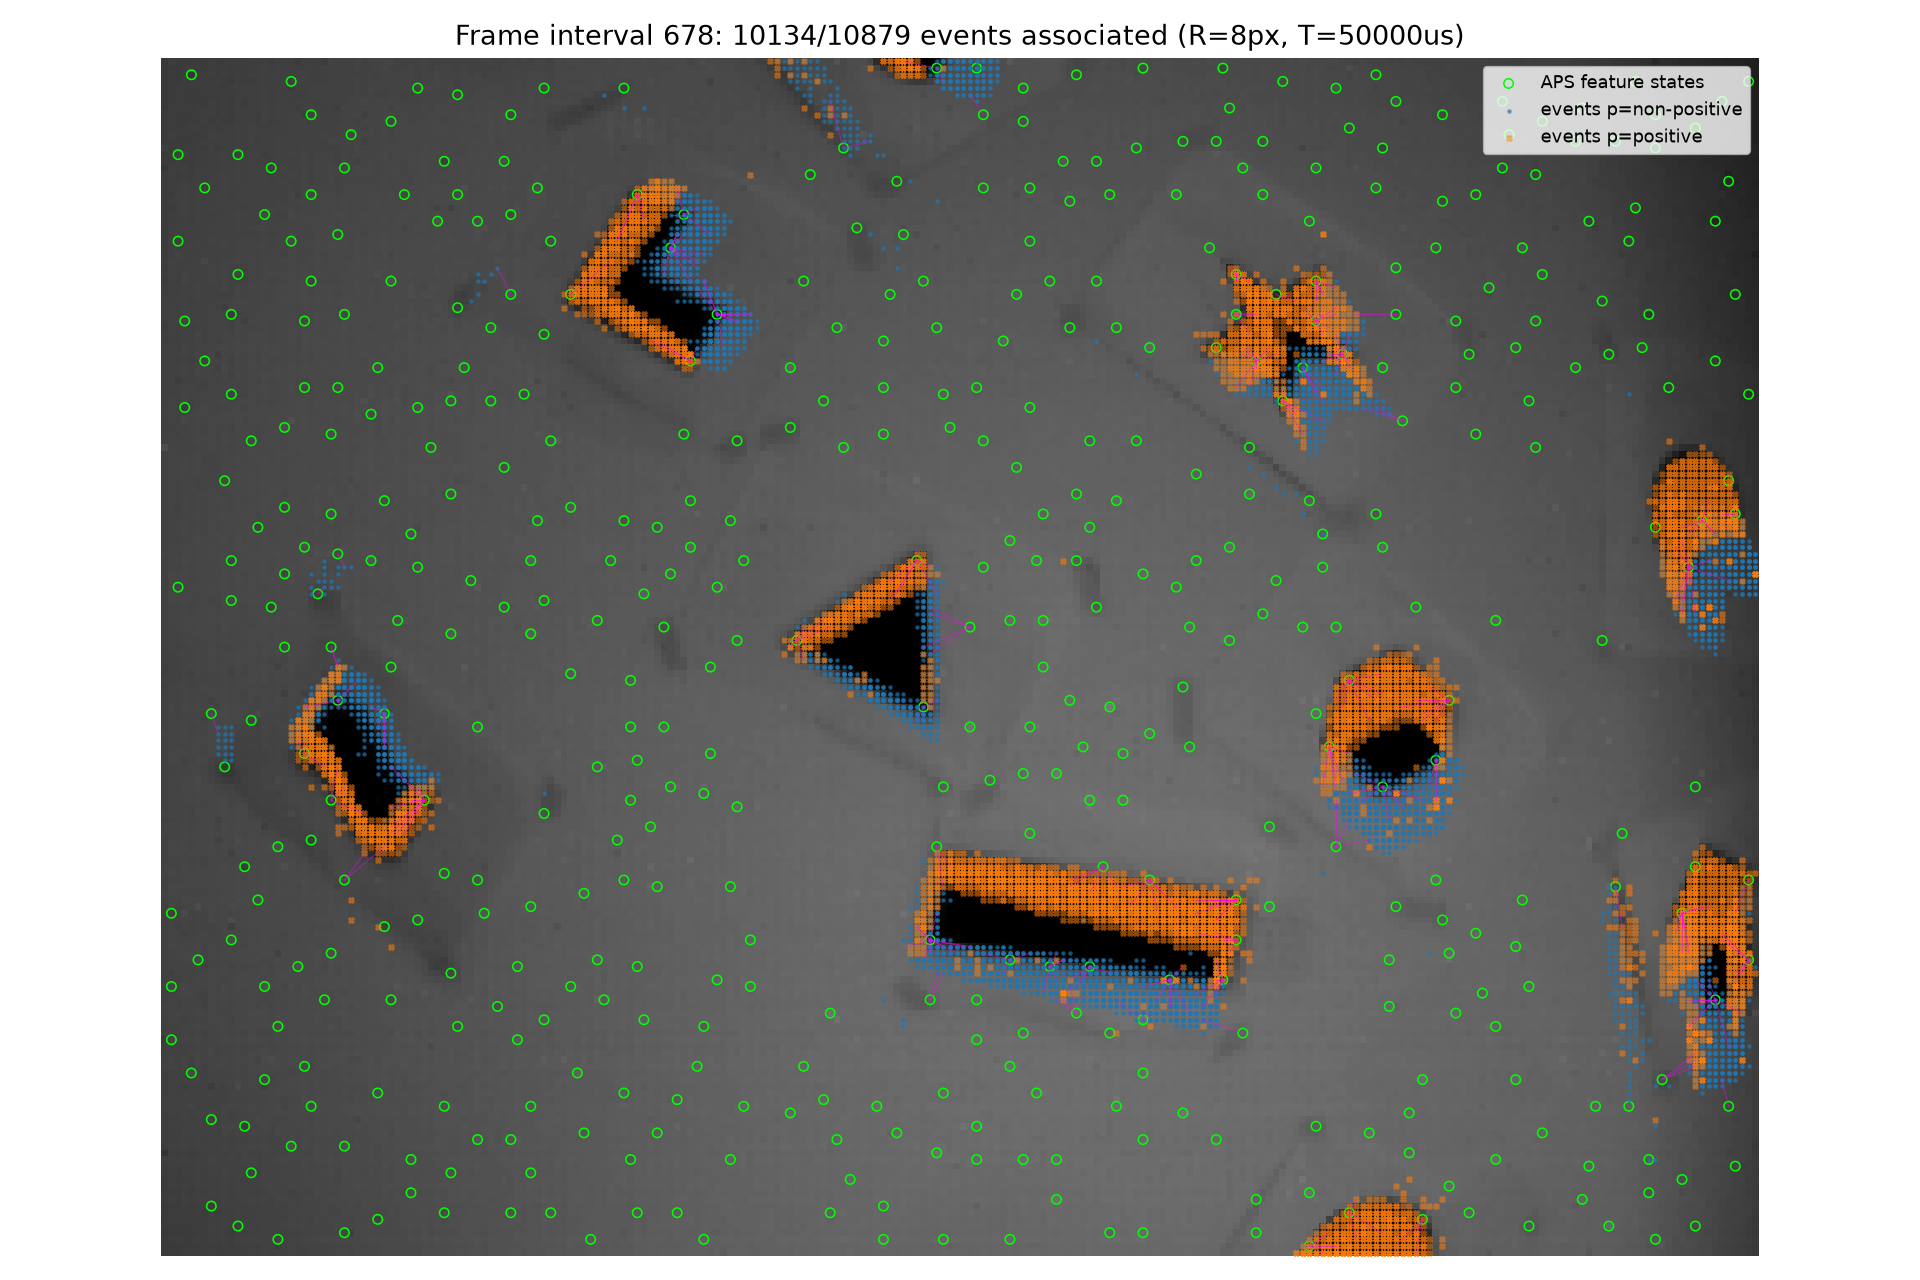

In [2]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
display(Image(filename=str(outputs["visualization"])))